Etapa 1 - EDA

## Importação e instalação das bibliotecas

In [1]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sklearn 

Leitura da base de dados

In [3]:
df = pd.read_csv(r"C:\Users\CPU\Downloads\DS_AeC\csv\articles.csv")

In [4]:
df.head()

,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


Etapa exploratória dos dados 
Verificação da estrutura da base, tipos de dados, quantidade de categorias, registros não nulos, frequencias nas categoris.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167053 entries, 0 to 167052
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   title        167053 non-null  str  
 1   text         166288 non-null  str  
 2   date         167053 non-null  str  
 3   category     167053 non-null  str  
 4   subcategory  29635 non-null   str  
 5   link         167053 non-null  str  
dtypes: str(6)
memory usage: 7.6 MB


In [6]:
df.isnull().sum()

title               0
text              765
date                0
category            0
subcategory    137418
link                0
dtype: int64

In [7]:
df["category"].nunique()

48

In [8]:
df["category"].value_counts()

category
poder                           22022
colunas                         21622
mercado                         20970
esporte                         19730
mundo                           17130
cotidiano                       16967
ilustrada                       16345
opiniao                          4525
paineldoleitor                   4011
saopaulo                         3955
tec                              2260
tv                               2142
educacao                         2118
turismo                          1903
ilustrissima                     1411
ciencia                          1335
equilibrioesaude                 1312
sobretudo                        1057
bbc                               980
folhinha                          876
empreendedorsocial                841
comida                            828
asmais                            548
ambiente                          491
seminariosfolha                   379
serafina                          334
o-m

Visualização da frequência de notícias por categoria.

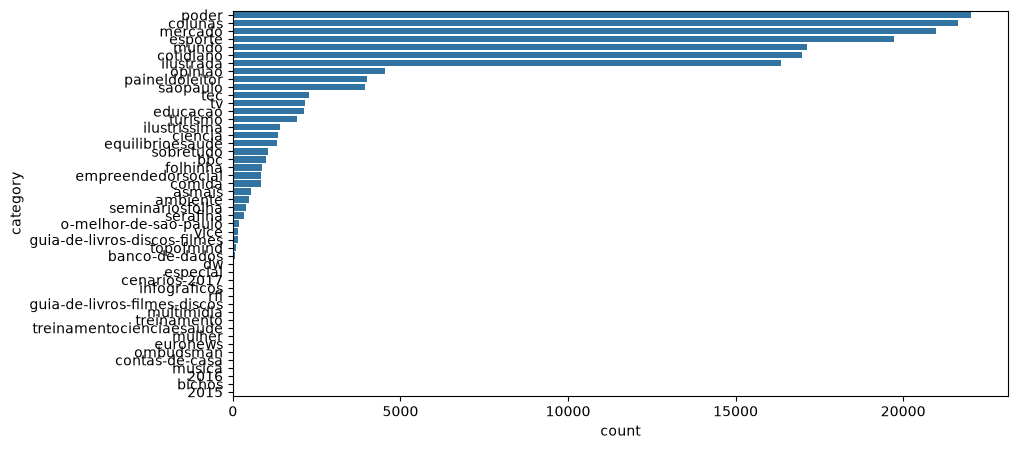

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index
)
plt.show()

Conversão da coluna de data para formato datetime, permitindo análises temporais.

In [10]:
df["date"] = pd.to_datetime(df["date"])

Total de notícias por ano/categoria.

In [11]:
df.groupby(df["date"].dt.year).size()

date
2015    72734
2016    60139
2017    34180
dtype: int64

In [12]:
df.groupby([df["date"].dt.year,"category"]).size()

date  category   
2015  2015             1
      ambiente       107
      asmais         451
      bbc            950
      bichos           1
                    ... 
2017  sobretudo      547
      tec            190
      treinamento      1
      turismo        351
      tv             215
Length: 110, dtype: int64

In [13]:
tabela = df.groupby([df["date"].dt.year,"category"]).size().unstack(fill_value=0)

In [14]:
tabela

category,2015,2016,ambiente,asmais,banco-de-dados,bbc,bichos,cenarios-2017,ciencia,colunas,...,seminariosfolha,serafina,sobretudo,tec,topofmind,treinamento,treinamentocienciaesaude,turismo,tv,vice
date,,,,,,,,,,,,,,,,,,,,,
2015,1,0,107,451,0,950,1,0,529,7635,...,80,106,0,1519,38,17,17,871,758,146
2016,0,1,178,85,3,25,0,43,481,8160,...,106,139,510,551,48,3,1,681,1169,0
2017,0,0,206,12,61,5,0,0,325,5827,...,193,89,547,190,0,1,0,351,215,0


Tamanho do título das notícias em quantidade de caracteres.

In [15]:
df["title_length"] = df["title"].str.len()

<Axes: xlabel='title_length', ylabel='Count'>

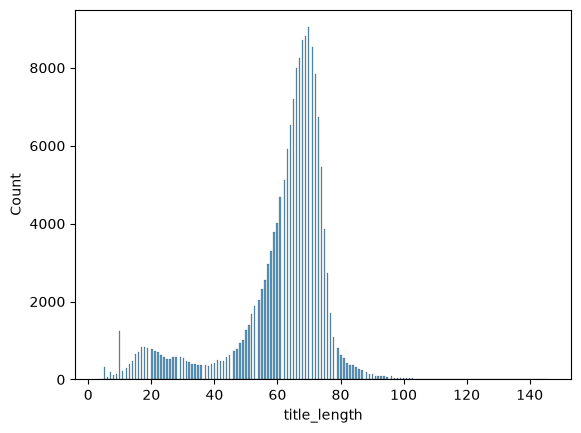

In [16]:
sns.histplot(df["title_length"])


In [17]:
df.groupby("category")["title_length"].mean().sort_values(ascending=False)

category
o-melhor-de-sao-paulo           78.523810
especial                        76.976744
asmais                          76.470803
2016                            73.000000
2015                            72.000000
treinamentocienciaesaude        71.055556
musica                          71.000000
rfi                             70.689655
sobretudo                       70.411542
saopaulo                        70.193173
esporte                         67.833046
serafina                        67.802395
folhinha                        67.299087
empreendedorsocial              67.036861
guia-de-livros-filmes-discos    66.928571
multimidia                      66.666667
educacao                        66.658640
cotidiano                       66.386869
cenarios-2017                   66.279070
seminariosfolha                 66.269129
guia-de-livros-discos-filmes    65.818182
mundo                           65.760712
turismo                         65.590121
mercado                  

In [18]:
df.groupby("category")["title_length"] \
  .mean() \
  .sort_values() \
  .head(10)

category
bichos            11.000000
infograficos      24.139535
opiniao           30.034696
ombudsman         40.333333
colunas           41.074322
contas-de-casa    54.000000
ilustrissima      55.795181
dw                58.604167
vice              59.123288
topofmind         59.883721
Name: title_length, dtype: float64

Etapa 2 - Pré processamento 

Função para tratamento do texto -> def clean_text(text):
    - Conversão para letras minúsculas
    - Remoção de caracteres especiais
    - Remoção de espaços excedentes
    

In [19]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zà-ú\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [20]:
df["title_clean"] = df["title"].apply(clean_text)

In [21]:
df.head()

,title,text,date,category,subcategory,link,title_length,title_clean
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...,72,lula diz que está lascado mas que ainda tem fo...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...,71,decidi ser escrava das mulheres que sofrem diz...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...,63,três reportagens da folha ganham prêmio petrob...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...,68,filme star wars os últimos jedi ganha trailer ...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...,70,cbss inicia acordos com fintechs e quer do cré...


Etapa 3 - BaseLine

Categorias com baixa representatividade podem prejudicar o treinamento do modelo.
Para aumentar a estabilidade das métricas, serão consideradas apenas categorias com pelo menos 10 registros.

In [22]:
df.columns

Index(['title', 'text', 'date', 'category', 'subcategory', 'link',
       'title_length', 'title_clean'],
      dtype='str')

In [23]:
# contagem das categorias
contagem = df["category"].value_counts()

# seleção categorias com pelo menos 10 observações
categorias_validas = contagem[contagem >= 10].index

# criação da base modelagem
df_modelo = df[df["category"].isin(categorias_validas)].copy()

# criação X e y DEPOIS do filtro para validação 
X = df_modelo["title"]
y = df_modelo["category"]


print(X.shape)
print(y.shape)

(167036,)
(167036,)


In [24]:
df_modelo.head()

,title,text,date,category,subcategory,link,title_length,title_clean
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...,72,lula diz que está lascado mas que ainda tem fo...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...,71,decidi ser escrava das mulheres que sofrem diz...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...,63,três reportagens da folha ganham prêmio petrob...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...,68,filme star wars os últimos jedi ganha trailer ...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...,70,cbss inicia acordos com fintechs e quer do cré...


Etapa 4 - Construção do Pipeline

Vetorização dos textos utilizando TF-IDF.
Treinamento do classificador Logistic Regression.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [26]:
pipeline = Pipeline([ #organiza as etapas treinamento do modelo em um único processo reutilizável/reprodutividade e evita vazamento de dados
    (
        "tfidf", #cria um vetor numerico(com pesos) classificando as palavras que mais aparecem no texto 
        TfidfVectorizer( 
            stop_words=None,
            max_features=10000, #limite de palavras mais relevantes
            ngram_range=(1,2) #unigramas= palavras unicas bigramas= pares palavras 
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000 #definição numero de iterações no treino
        )
    )
])

Etapa 5 - Train/Test Split

In [27]:
from sklearn.model_selection import train_test_split 

In [28]:
X_train, X_test, y_train, y_test = train_test_split( #divide o dataset em treino = 80% e teste = 20%
    df_modelo["title_clean"], #variavel explicativa
    df_modelo["category"], #variavel alvo
    test_size=0.2, #%teste
    random_state=42, #semente para garantir a reprodutividade
    stratify=df_modelo["category"] # mantém a proporção no treino e teste
)

Etapa 6 - Treinamento

In [29]:
# Treina simultaneamente o vetor TF-IDF e o modelo Logistic Regression/retorna diagrama com a arquitetura do modelo/acesso documentação
pipeline.fit(X_train, y_train) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](41,)","['ambiente','asmais','banco-de-dados',...,'turismo','tv','vice']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


Etapa 7 - Teste

Calculo das métricas de classificação para avaliar a capacidade preditiva do modelo.

In [30]:
from sklearn.metrics import classification_report

In [31]:
pred = pipeline.predict(X_test)

print(
    classification_report(
        y_test,
        pred
    )
)

C:\Users\CPU\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\CPU\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                              precision    recall  f1-score   support

                    ambiente       0.46      0.06      0.11        98
                      asmais       0.26      0.05      0.08       110
              banco-de-dados       0.00      0.00      0.00        13
                         bbc       0.33      0.01      0.01       196
               cenarios-2017       0.00      0.00      0.00         9
                     ciencia       0.68      0.26      0.37       267
                     colunas       0.54      0.63      0.58      4324
                      comida       0.56      0.16      0.25       166
                   cotidiano       0.71      0.81      0.76      3393
                          dw       0.00      0.00      0.00        10
                    educacao       0.72      0.62      0.67       424
          empreendedorsocial       0.73      0.29      0.41       168
            equilibrioesaude       0.54      0.21      0.30       262
                   

C:\Users\CPU\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Matriz de confusão para análise dos acertos e erros de classificação.

### Resultados

O modelo apresentou desempenho satisfatório na classificação de notícias, alcançando 72% de acurácia. 
As métricas de precisão (70%), recall (72%) e F1-score (69%) indicam um equilíbrio entre a capacidade de identificar corretamente as categorias e reduzir classificações incorretas.


In [32]:
from sklearn.metrics import confusion_matrix

In [33]:
cm = confusion_matrix(y_test, pred)

In [34]:
print(cm)

[[  6   0   0 ...   2   0   0]
 [  0   5   0 ...   4   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0   1   0 ... 134   1   0]
 [  0   0   0 ...   1  29   0]
 [  0   0   0 ...   0   0   0]]


In [35]:
from sklearn.metrics import confusion_matrix

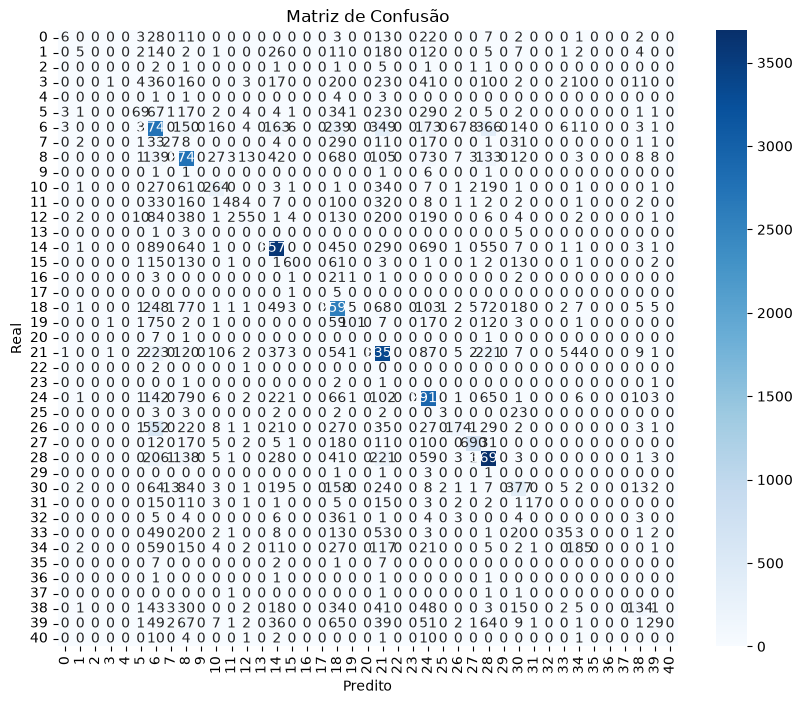

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")

plt.show()

In [37]:
classes = sorted(y_test.unique())

for i, classe in enumerate(classes):
    print(i, classe)

0 ambiente
1 asmais
2 banco-de-dados
3 bbc
4 cenarios-2017
5 ciencia
6 colunas
7 comida
8 cotidiano
9 dw
10 educacao
11 empreendedorsocial
12 equilibrioesaude
13 especial
14 esporte
15 folhinha
16 guia-de-livros-discos-filmes
17 guia-de-livros-filmes-discos
18 ilustrada
19 ilustrissima
20 infograficos
21 mercado
22 mulher
23 multimidia
24 mundo
25 o-melhor-de-sao-paulo
26 opiniao
27 paineldoleitor
28 poder
29 rfi
30 saopaulo
31 seminariosfolha
32 serafina
33 sobretudo
34 tec
35 topofmind
36 treinamento
37 treinamentocienciaesaude
38 turismo
39 tv
40 vice


Etapa 8 - Salvando o modelo treinado

O pipeline completo é salvo utilizando Joblib para uso em produção e integração com a API.

In [38]:
!pip install fastapi
from fastapi import FastAPI
from pydantic import BaseModel
import joblib



In [39]:
app = FastAPI()
joblib.dump(
    pipeline,
    r"C:\Users\CPU\Downloads\DS_AeC\api\news_classifier.pkl"
)

['C:\\Users\\CPU\\Downloads\\DS_AeC\\api\\news_classifier.pkl']

In [40]:
modelo = joblib.load(
    r"C:\Users\CPU\Downloads\DS_AeC\api\news_classifier.pkl"
)

Teste utilizando um exemplo de notícia não vista durante o treinamento.

In [41]:
modelo.predict([
    "Seleção brasileira vence amistoso por três a zero"
])

array(['esporte'], dtype=object)

Etapa 9 - API

Após o treinamento, o modelo é disponibilizado através de uma API FastAPI, permitindo que novas notícias sejam classificadas em tempo real.

api       -> pasta da aplicação

main      -> arquivo main.py

app       -> instancia FastAPI - variável app = FastAPI()

predict   -> endpoint de classificação


cmd
cd C:\Users\CPU\Downloads\DS_AeC

pip install fastapi uvicorn

uvicorn api.main:app --reload

In [42]:
app = FastAPI()

model = joblib.load(r"C:\Users\CPU\Downloads\DS_AeC\api\news_classifier.pkl")

class NewsRequest(BaseModel): #valida automaticamente os dados recebidos pela API, reduz erro de entrada/tipo string
    title: str

@app.get("/")
def home():
    return {"status": "running"}

@app.post("/predict")
def predict(data: NewsRequest):

    pred = model.predict([data.title])[0]

    return {
        "title": data.title,
        "categoria_predita": pred
    }

# Considerações
- Foi realizado um processo completo de classificação de notícias utilizando NLP.
- Os títulos foram tratados e transformados em vetores numéricos através de TF-IDF.
- O modelo Logistic Regression apresentou desempenho satisfatório para o problema proposto
- O modelo foi disponibilizado por meio de uma API FastAPI, permitindo seu consumo em aplicações externas.